Inisialisasi Library

In [1]:
import pandas as pd
import string
import re
import nltk
from nltk import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import swifter

from wordcloud import WordCloud
import matplotlib.pyplot as plt

import gensim
from gensim import corpora
from gensim.models import LdaModel
from gensim.models import CoherenceModel

import joblib
import matplotlib.pyplot as plt
import pyLDAvis
import pyLDAvis.gensim

from sklearn import model_selection 
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE

from sklearn import svm

import pickle
import os

c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Reading Data

In [2]:
df = pd.read_csv('dataArtikel_JTIIK_final.csv', sep = ',', encoding = 'ISO-8859-1')
df.head()

,Title,Abstract,Casefolding,abs_id,key_id,abs_eng,key_eng
0,Pengembangan Metode Klasifikasi Berdasarkan K-...,AbstrakPada penelitian ini dikembangkan metode...,abstrakpada penelitian ini dikembangkan metode...,pada penelitian ini dikembangkan metode klasif...,klasifikasi pengelompokan k means lvq,this research will develop methods of classifi...,classification grouping k means lvq
1,Implementasi Teknik Watershed Dan Morfologi Pa...,AbstrakPenelitian di bidang segmentasi citra t...,abstrakpenelitian di bidang segmentasi citra t...,penelitian di bidang segmentasi citra telah ba...,watershed morfologi citra citra satelit,research in the field of image segmentation ha...,watershed morphological image satellite imagery
2,Audit Dan Investigasi Sistem Keamanan Jaringan...,AbstrakPemanfaatan internet untuk bidang pendi...,abstrakpemanfaatan internet untuk bidang pendi...,pemanfaatan internet untuk bidang pendidikan t...,snort indeks kami network attack,utilization of the internet for education has ...,snort kami indeks network attack
3,Prediksi Cuaca Pada Data Time Series Menggunak...,AbstrakInformasi mengenai kondisi atmosfer yan...,abstrakinformasi mengenai kondisi atmosfer yan...,informasi mengenai kondisi atmosfer yang cepat...,prediksi cuaca peramalan cuaca data time seri...,rapid and accurate information on the atmosphe...,weather prediction weather forecasting time s...
4,Implementasi Sensor Cahaya Sebagai Pengontrol ...,"Abstrak Dengan menggabungkan Sistem Kontrol, s...",abstrak dengan menggabungkan sistem kontrol s...,dengan menggabungkan sistem kontrol sensor da...,robot kesetimbangan sensor cahaya pid kontroler,by combining the control system sensors and s...,self balancing robot light sensor pid contro...


Periksa dataset

In [3]:
df.shape


(1158, 7)

In [4]:
df.dtypes

Title          object
Abstract       object
Casefolding    object
abs_id         object
key_id         object
abs_eng        object
key_eng        object
dtype: object

In [5]:
df = df.drop(columns=['Casefolding', 'key_id', 'abs_eng', 'key_eng'])

In [6]:
# menampilkan data yang terdapat missing values
missing_abst = df[df.isna().any(axis=1)]
print(missing_abst)

                                   Title                            Abstract  \
263    Halaman Belakang & Daftar Indeks     Halaman Belakang & Daftar Indeks   
280    Halaman Belakang & Daftar Indeks     Halaman Belakang & Daftar Indeks   
287    Halaman Belakang & Daftar Indeks     Halaman Belakang & Daftar Indeks   
306    Halaman Belakang & Daftar Indeks     Halaman Belakang & Daftar Indeks   
315    Halaman Belakang & Daftar Indeks     Halaman Belakang & Daftar Indeks   
343  Halaman Belakang dan Daftar Indeks   Halaman Belakang dan Daftar Indeks   
366  Halaman Belakang dan Daftar Indeks   Halaman Belakang dan Daftar Indeks   
412  Halaman Belakang dan Daftar Indeks   Halaman Belakang dan Daftar Indeks   
450  Halaman Belakang dan Daftar Indeks   Halaman Belakang dan Daftar Indeks   
474  Halaman Belakang dan Daftar Indeks   Halaman Belakang dan Daftar Indeks   
526  Halaman Belakang dan Daftar Indeks   Halaman Belakang dan Daftar Indeks   
540  Halaman Belakang dan Daftar Indeks 

In [7]:
# untuk menghapus baris data yg memiliki missing value
df = df.dropna()

In [8]:
df.isna().sum()

Title       0
Abstract    0
abs_id      0
dtype: int64

In [9]:
# mengecek data duplikat
df.duplicated().any()

True

In [10]:
df.shape

(1138, 3)

# Preprocessing

## Case Folding

In [11]:
def casefolding(text):
    text = text.lower()
    text = re.sub(r"[-()\"#/@;:<>{}'+=%~|.!?,_]", " ", text)
    return text

df['Casefolding'] = df['abs_id'].apply(casefolding)
df.head()

,Title,Abstract,abs_id,Casefolding
0,Pengembangan Metode Klasifikasi Berdasarkan K-...,AbstrakPada penelitian ini dikembangkan metode...,pada penelitian ini dikembangkan metode klasif...,pada penelitian ini dikembangkan metode klasif...
1,Implementasi Teknik Watershed Dan Morfologi Pa...,AbstrakPenelitian di bidang segmentasi citra t...,penelitian di bidang segmentasi citra telah ba...,penelitian di bidang segmentasi citra telah ba...
2,Audit Dan Investigasi Sistem Keamanan Jaringan...,AbstrakPemanfaatan internet untuk bidang pendi...,pemanfaatan internet untuk bidang pendidikan t...,pemanfaatan internet untuk bidang pendidikan t...
3,Prediksi Cuaca Pada Data Time Series Menggunak...,AbstrakInformasi mengenai kondisi atmosfer yan...,informasi mengenai kondisi atmosfer yang cepat...,informasi mengenai kondisi atmosfer yang cepat...
4,Implementasi Sensor Cahaya Sebagai Pengontrol ...,"Abstrak Dengan menggabungkan Sistem Kontrol, s...",dengan menggabungkan sistem kontrol sensor da...,dengan menggabungkan sistem kontrol sensor da...


## Tokenizing

In [12]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [13]:
def word_tokenize_wrapper(text):
    return word_tokenize(text)

df['Tokenizing'] = df['Casefolding'].apply(word_tokenize_wrapper)
df.head()

,Title,Abstract,abs_id,Casefolding,Tokenizing
0,Pengembangan Metode Klasifikasi Berdasarkan K-...,AbstrakPada penelitian ini dikembangkan metode...,pada penelitian ini dikembangkan metode klasif...,pada penelitian ini dikembangkan metode klasif...,"[pada, penelitian, ini, dikembangkan, metode, ..."
1,Implementasi Teknik Watershed Dan Morfologi Pa...,AbstrakPenelitian di bidang segmentasi citra t...,penelitian di bidang segmentasi citra telah ba...,penelitian di bidang segmentasi citra telah ba...,"[penelitian, di, bidang, segmentasi, citra, te..."
2,Audit Dan Investigasi Sistem Keamanan Jaringan...,AbstrakPemanfaatan internet untuk bidang pendi...,pemanfaatan internet untuk bidang pendidikan t...,pemanfaatan internet untuk bidang pendidikan t...,"[pemanfaatan, internet, untuk, bidang, pendidi..."
3,Prediksi Cuaca Pada Data Time Series Menggunak...,AbstrakInformasi mengenai kondisi atmosfer yan...,informasi mengenai kondisi atmosfer yang cepat...,informasi mengenai kondisi atmosfer yang cepat...,"[informasi, mengenai, kondisi, atmosfer, yang,..."
4,Implementasi Sensor Cahaya Sebagai Pengontrol ...,"Abstrak Dengan menggabungkan Sistem Kontrol, s...",dengan menggabungkan sistem kontrol sensor da...,dengan menggabungkan sistem kontrol sensor da...,"[dengan, menggabungkan, sistem, kontrol, senso..."


## Stopwords Removal

In [14]:
stopwords_indo = set(stopwords.words('indonesian'))

def stopwordText(text):
    return[word for word in text if word not in stopwords_indo] 

df['Stopwords'] = df['Tokenizing'].apply(stopwordText)
data_stopwords = df['Stopwords']
df.head()

,Title,Abstract,abs_id,Casefolding,Tokenizing,Stopwords
0,Pengembangan Metode Klasifikasi Berdasarkan K-...,AbstrakPada penelitian ini dikembangkan metode...,pada penelitian ini dikembangkan metode klasif...,pada penelitian ini dikembangkan metode klasif...,"[pada, penelitian, ini, dikembangkan, metode, ...","[penelitian, dikembangkan, metode, klasifikasi..."
1,Implementasi Teknik Watershed Dan Morfologi Pa...,AbstrakPenelitian di bidang segmentasi citra t...,penelitian di bidang segmentasi citra telah ba...,penelitian di bidang segmentasi citra telah ba...,"[penelitian, di, bidang, segmentasi, citra, te...","[penelitian, bidang, segmentasi, citra, bidang..."
2,Audit Dan Investigasi Sistem Keamanan Jaringan...,AbstrakPemanfaatan internet untuk bidang pendi...,pemanfaatan internet untuk bidang pendidikan t...,pemanfaatan internet untuk bidang pendidikan t...,"[pemanfaatan, internet, untuk, bidang, pendidi...","[pemanfaatan, internet, bidang, pendidikan, me..."
3,Prediksi Cuaca Pada Data Time Series Menggunak...,AbstrakInformasi mengenai kondisi atmosfer yan...,informasi mengenai kondisi atmosfer yang cepat...,informasi mengenai kondisi atmosfer yang cepat...,"[informasi, mengenai, kondisi, atmosfer, yang,...","[informasi, kondisi, atmosfer, cepat, akurat, ..."
4,Implementasi Sensor Cahaya Sebagai Pengontrol ...,"Abstrak Dengan menggabungkan Sistem Kontrol, s...",dengan menggabungkan sistem kontrol sensor da...,dengan menggabungkan sistem kontrol sensor da...,"[dengan, menggabungkan, sistem, kontrol, senso...","[menggabungkan, sistem, kontrol, sensor, motor..."


In [15]:
df = df[df['Stopwords'].apply(lambda x: len(x)>0)]

## Stemming

In [16]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

exception_words = {"bali"}

def stemmed_wrapper(term):
    if term in exception_words:
        return term
    return stemmer.stem(term)

term_dict = {}

for document in df['Stopwords']:
    for term in document:
        if term not in term_dict:
            term_dict[term] = ' '

# Melakukan Stemming untuk setiap kata
for term in term_dict:
    term_dict[term] = stemmed_wrapper(term)
    print(term, ":", term_dict[term])

# Fungsi Stemming untuk Dokumen
def stemmingText(document):
    return [term_dict.get(term, term) for term in document]

df['Stemming'] = df['Stopwords'].swifter.apply(stemmingText)

penelitian : teliti
dikembangkan : kembang
metode : metode
klasifikasi : klasifikasi
berdasarkan : dasar
pengelompokan : kelompok
k : k
means : means
lvq : lvq
data : data
frekuensi : frekuensi
cenderung : cenderung
pengujian : uji
kelas : kelas
bermanfaat : manfaat
langkah : langkah
pengelompokkan : kelompok
mencapai : capai
threshold : threshold
batasan : batas
dicapai : capai
cluster : cluster
berbeda : beda
pembelajaran : ajar
akurasi : akurasi
gabungan : gabung
murni : murni
untukì£åâ : untuk
tertinggi : tinggi
didapatkan : dapat
92 : 92
82 : 82
bidang : bidang
segmentasi : segmentasi
citra : citra
satelit : satelit
proses : proses
deteksi : deteksi
objek : objek
diimplementasikan : implementasi
teknik : teknik
watershed : watershed
morfologi : morfologi
diubah : ubah
format : format
grayscale : grayscale
diolah : olah
diperbaiki : baik
mengurangi : kurang
berlebih : lebih
dihasilkan : hasil
uji : uji
coba : coba
5dataset : 5dataset
satelitarea : satelitarea
universitas : universi

Pandas Apply: 100%|██████████| 1138/1138 [00:00<00:00, 7923.66it/s]


## Proses Penggabungan kembali Kata Menjadi Sebuah Kalimat

In [17]:
def remove_punct(text):
    text = ' '.join([char for char in text if char not in string.punctuation])
    return text

df['Clean_noStemming'] = df['Stopwords'].apply(lambda x: remove_punct(x))
df['Clean'] = df['Stemming'].apply(lambda x: remove_punct(x))
df.head(10)

,Title,Abstract,abs_id,Casefolding,Tokenizing,Stopwords,Stemming,Clean_noStemming,Clean
0,Pengembangan Metode Klasifikasi Berdasarkan K-...,AbstrakPada penelitian ini dikembangkan metode...,pada penelitian ini dikembangkan metode klasif...,pada penelitian ini dikembangkan metode klasif...,"[pada, penelitian, ini, dikembangkan, metode, ...","[penelitian, dikembangkan, metode, klasifikasi...","[teliti, kembang, metode, klasifikasi, dasar, ...",penelitian dikembangkan metode klasifikasi ber...,teliti kembang metode klasifikasi dasar kelomp...
1,Implementasi Teknik Watershed Dan Morfologi Pa...,AbstrakPenelitian di bidang segmentasi citra t...,penelitian di bidang segmentasi citra telah ba...,penelitian di bidang segmentasi citra telah ba...,"[penelitian, di, bidang, segmentasi, citra, te...","[penelitian, bidang, segmentasi, citra, bidang...","[teliti, bidang, segmentasi, citra, bidang, ci...",penelitian bidang segmentasi citra bidang citr...,teliti bidang segmentasi citra bidang citra sa...
2,Audit Dan Investigasi Sistem Keamanan Jaringan...,AbstrakPemanfaatan internet untuk bidang pendi...,pemanfaatan internet untuk bidang pendidikan t...,pemanfaatan internet untuk bidang pendidikan t...,"[pemanfaatan, internet, untuk, bidang, pendidi...","[pemanfaatan, internet, bidang, pendidikan, me...","[manfaat, internet, bidang, didik, bantu, civi...",pemanfaatan internet bidang pendidikan membant...,manfaat internet bidang didik bantu civitas ak...
3,Prediksi Cuaca Pada Data Time Series Menggunak...,AbstrakInformasi mengenai kondisi atmosfer yan...,informasi mengenai kondisi atmosfer yang cepat...,informasi mengenai kondisi atmosfer yang cepat...,"[informasi, mengenai, kondisi, atmosfer, yang,...","[informasi, kondisi, atmosfer, cepat, akurat, ...","[informasi, kondisi, atmosfer, cepat, akurat, ...",informasi kondisi atmosfer cepat akurat terper...,informasi kondisi atmosfer cepat akurat perinc...
4,Implementasi Sensor Cahaya Sebagai Pengontrol ...,"Abstrak Dengan menggabungkan Sistem Kontrol, s...",dengan menggabungkan sistem kontrol sensor da...,dengan menggabungkan sistem kontrol sensor da...,"[dengan, menggabungkan, sistem, kontrol, senso...","[menggabungkan, sistem, kontrol, sensor, motor...","[gabung, sistem, kontrol, sensor, motor, servo...",menggabungkan sistem kontrol sensor motor serv...,gabung sistem kontrol sensor motor servo harap...
5,Pencarian Ruang Warna Kulit Manusia Berdasarka...,Abstrak Perkembangan transaksi dan distribusi ...,perkembangan transaksi dan distribusi data yan...,perkembangan transaksi dan distribusi data yan...,"[perkembangan, transaksi, dan, distribusi, dat...","[perkembangan, transaksi, distribusi, data, te...","[kembang, transaksi, distribusi, data, teknolo...",perkembangan transaksi distribusi data teknolo...,kembang transaksi distribusi data teknologi in...
6,Analisa Pengaruh Mobilitas Node Terhadap Kuali...,Abstrak IMS (IP Multimedia Subsystem) adalah b...,ims ip multimedia subsystem adalah bagian da...,ims ip multimedia subsystem adalah bagian da...,"[ims, ip, multimedia, subsystem, adalah, bagia...","[ims, ip, multimedia, subsystem, spesifikasi, ...","[ims, ip, multimedia, subsystem, spesifikasi, ...",ims ip multimedia subsystem spesifikasi umts u...,ims ip multimedia subsystem spesifikasi umts u...
7,Peringkasan Dokumen Bahasa Indonesia Berbasis ...,Abstrak Peningkatan teknologi informasi telah ...,peningkatan teknologi informasi telah memicu p...,peningkatan teknologi informasi telah memicu p...,"[peningkatan, teknologi, informasi, telah, mem...","[peningkatan, teknologi, informasi, memicu, pe...","[tingkat, teknologi, informasi, picu, tingkat,...",peningkatan teknologi informasi memicu peningk...,tingkat teknologi informasi picu tingkat dokum...
8,Rancang Bangun Sistem Administrasi Akademik Be...,Abstrak E-Kiosk adalah suatu sistem vending ma...,e kiosk adalah suatu sistem vending machine in...,e kiosk adalah suatu sistem vending machine in...,"[e, kiosk, adalah, suatu, sistem, vending, mac...

In [18]:
allText_forLDA = " ".join(df['Clean_noStemming'])

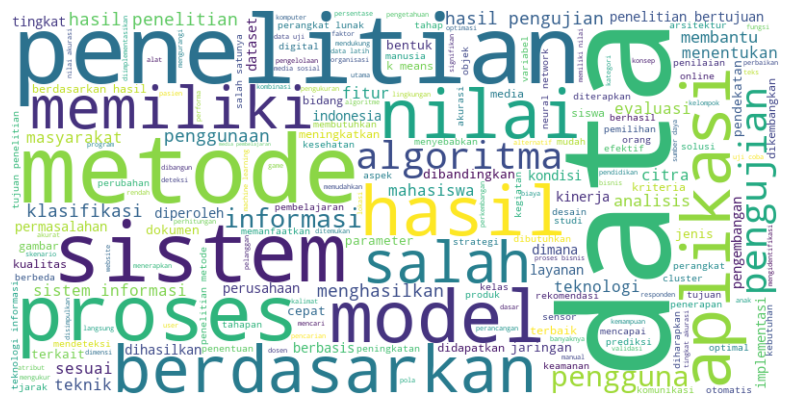

In [19]:
# tampilkan wordcloud hasil preprocessing
words = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords_indo).generate(allText_forLDA)
plt.figure(figsize=(10, 5))
plt.imshow(words, interpolation='bilinear')
plt.axis('off')
plt.show()

## Simpan Hasil Preprocessing

In [20]:
df.to_csv('dataClean_noKey.csv', index=False)

## Bigram dan Trigram

In [21]:
# membuat model bigram dan trigram
bigram = gensim.models.Phrases(data_stopwords, min_count=5, threshold=5)
trigram = gensim.models.Phrases(bigram[data_stopwords], threshold=5)

bigram_mod = gensim.models.phrases.Phraser(bigram)
trigram_mod = gensim.models.phrases.Phraser(trigram)

# fungsi untuk membuat bigram dan trigram models

def make_bigrams(texts):
    return[bigram_mod[doc] for doc in texts]

def make_trigrams(texts):
    return[trigram_mod[bigram_mod[doc]] for doc in texts]

# Create data bigrams
data_bigram = make_bigrams(data_stopwords)

# Create data bigrams
data_trigram = make_trigrams(data_stopwords)

In [22]:
print(data_bigram[0])
print(data_trigram[0])
print(data_bigram[1])
print(data_trigram[1])
print(data_bigram[2])
print(data_trigram[2])
print(data_bigram[3])
print(data_trigram[3])
print(data_bigram[4])
print(data_trigram[4])
print(data_bigram[5])
print(data_trigram[5])

['penelitian_dikembangkan', 'metode_klasifikasi', 'berdasarkan', 'pengelompokan', 'k_means', 'lvq', 'metode', 'metode_klasifikasi', 'data', 'frekuensi', 'cenderung', 'pengujian', 'kelas', 'data', 'bermanfaat', 'langkah', 'pengelompokan', 'pengelompokkan', 'k_means', 'pengelompokan', 'mencapai', 'threshold', 'batasan', 'threshold', 'dicapai', 'cluster', 'kelas', 'berbeda', 'pembelajaran', 'lvq', 'akurasi', 'gabungan', 'k_means', 'lvq', 'k_means', 'murni', 'untukì£åâ', 'akurasi_tertinggi', 'k_means', 'lvq', 'didapatkan', '92', 'k_means', 'murni', '82']
['penelitian_dikembangkan', 'metode_klasifikasi', 'berdasarkan', 'pengelompokan', 'k_means_lvq', 'metode', 'metode_klasifikasi', 'data', 'frekuensi', 'cenderung', 'pengujian', 'kelas', 'data', 'bermanfaat', 'langkah', 'pengelompokan', 'pengelompokkan', 'k_means', 'pengelompokan', 'mencapai', 'threshold', 'batasan', 'threshold', 'dicapai', 'cluster', 'kelas', 'berbeda', 'pembelajaran', 'lvq', 'akurasi', 'gabungan', 'k_means_lvq', 'k_means',

# Pelabelan

Read Data Clean

In [23]:
df = pd.read_csv('dataClean_noKey.csv')

## Latent Dirichlet Allocation

In [24]:
# membuat dictionary dan corpus

dictionary = corpora.Dictionary(data_trigram)                                     # Membuat kamus dari daftar kata unik dalam dataset.
corpus = [dictionary.doc2bow(doc) for doc in data_trigram]                        # doc2bow(doc): Mengubah setiap dokumen menjadi representasi bag-of-words (BoW), di mana:
#                                                                                      - Setiap kata diberikan ID unik.
#                                                                                      - Representasi dokumen berupa daftar pasangan (ID_kata, frekuensi).

In [25]:
k_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
perplexities = []
coherences = []

In [26]:
# uji coba coherence topik tertinggi
for k in k_values:
    lda_model = LdaModel(corpus, num_topics=k, id2word=dictionary, passes=10, random_state=42, alpha=0.1)

    # hitung perplexity
    perplexity = lda_model.log_perplexity(corpus)
    perplexities.append(perplexity)

    # hitung coherence score
    coherence_model = CoherenceModel(model=lda_model, texts=data_trigram, dictionary=dictionary, coherence='c_v')
    coherence_score = coherence_model.get_coherence()
    coherences.append(coherence_score)
    print(f"Jumlah Topik: {k} | Perplexity: {perplexity:.4f} | Coherence Score: {coherence_score:4f}")

Jumlah Topik: 1 | Perplexity: -8.5343 | Coherence Score: 0.193226
Jumlah Topik: 2 | Perplexity: -8.5116 | Coherence Score: 0.212823
Jumlah Topik: 3 | Perplexity: -8.5138 | Coherence Score: 0.196691
Jumlah Topik: 4 | Perplexity: -8.5133 | Coherence Score: 0.209704
Jumlah Topik: 5 | Perplexity: -8.5267 | Coherence Score: 0.201049
Jumlah Topik: 6 | Perplexity: -8.5298 | Coherence Score: 0.202448
Jumlah Topik: 7 | Perplexity: -8.5391 | Coherence Score: 0.209117
Jumlah Topik: 8 | Perplexity: -8.5460 | Coherence Score: 0.213329
Jumlah Topik: 9 | Perplexity: -8.5545 | Coherence Score: 0.217849
Jumlah Topik: 10 | Perplexity: -8.5615 | Coherence Score: 0.209000


In [27]:
#  model untuk k= 9
lda_model = LdaModel(corpus, num_topics=9, id2word=dictionary, passes=10, random_state=42, alpha=0.1)

In [28]:
# Menentukan topik dominan untuk setiap dokumen

dominant_topics = []
for i, doc_bow in enumerate(corpus):
    # Mendapatkan distribusi topik untuk dokumen saat ini
    topic_distribution = lda_model.get_document_topics(doc_bow, minimum_probability=0.0)

    # Mengurutkan topik berdasarkan probabilitas dan ambil yang tertinggi
    # topic_distribution adalah list of (topic_id, probability)
    if topic_distribution: # Pastikan ada topik yang ditemukan
        dominant_topic_id = max(topic_distribution, key=lambda x: x[1])[0]
        dominant_topics.append(dominant_topic_id)
    else:
        dominant_topics.append(-1)

df['Topik'] = dominant_topics

In [29]:
df.head()

,Title,Abstract,abs_id,Casefolding,Tokenizing,Stopwords,Stemming,Clean_noStemming,Clean,Topik
0,Pengembangan Metode Klasifikasi Berdasarkan K-...,AbstrakPada penelitian ini dikembangkan metode...,pada penelitian ini dikembangkan metode klasif...,pada penelitian ini dikembangkan metode klasif...,"['pada', 'penelitian', 'ini', 'dikembangkan', ...","['penelitian', 'dikembangkan', 'metode', 'klas...","['teliti', 'kembang', 'metode', 'klasifikasi',...",penelitian dikembangkan metode klasifikasi ber...,teliti kembang metode klasifikasi dasar kelomp...,6
1,Implementasi Teknik Watershed Dan Morfologi Pa...,AbstrakPenelitian di bidang segmentasi citra t...,penelitian di bidang segmentasi citra telah ba...,penelitian di bidang segmentasi citra telah ba...,"['penelitian', 'di', 'bidang', 'segmentasi', '...","['penelitian', 'bidang', 'segmentasi', 'citra'...","['teliti', 'bidang', 'segmentasi', 'citra', 'b...",penelitian bidang segmentasi citra bidang citr...,teliti bidang segmentasi citra bidang citra sa...,7
2,Audit Dan Investigasi Sistem Keamanan Jaringan...,AbstrakPemanfaatan internet untuk bidang pendi...,pemanfaatan internet untuk bidang pendidikan t...,pemanfaatan internet untuk bidang pendidikan t...,"['pemanfaatan', 'internet', 'untuk', 'bidang',...","['pemanfaatan', 'internet', 'bidang', 'pendidi...","['manfaat', 'internet', 'bidang', 'didik', 'ba...",pemanfaatan internet bidang pendidikan membant...,manfaat internet bidang didik bantu civitas ak...,7
3,Prediksi Cuaca Pada Data Time Series Menggunak...,AbstrakInformasi mengenai kondisi atmosfer yan...,informasi mengenai kondisi atmosfer yang cepat...,informasi mengenai kondisi atmosfer yang cepat...,"['informasi', 'mengenai', 'kondisi', 'atmosfer...","['informasi', 'kondisi', 'atmosfer', 'cepat', ...","['informasi', 'kondisi', 'atmosfer', 'cepat', ...",informasi kondisi atmosfer cepat akurat terper...,informasi kondisi atmosfer cepat akurat perinc...,3
4,Implementasi Sensor Cahaya Sebagai Pengontrol ...,"Abstrak Dengan menggabungkan Sistem Kontrol, s...",dengan menggabungkan sistem kontrol sensor da...,dengan menggabungkan sistem kontrol sensor da...,"['dengan', 'menggabungkan', 'sistem', 'kontrol...","['menggabungkan', 'sistem', 'kontrol', 'sensor...","['gabung', 'sistem', 'kontrol', 'sensor', 'mot...",menggabungkan sistem kontrol sensor motor serv...,gabung sistem kontrol sensor motor servo harap...,6


In [30]:
words = 50

# Menampilkan kata-kata kunci untuk setiap topik
print(f"Kata-kata kunci untuk setiap topik (Top {words} kata):")

for idx, topic in lda_model.print_topics(num_words=words):
    print(f"Topik {idx}: \n{topic}")

Kata-kata kunci untuk setiap topik (Top 50 kata):
Topik 0: 
0.011*"penelitian" + 0.009*"model" + 0.007*"data" + 0.006*"metode" + 0.005*"sistem" + 0.005*"berdasarkan" + 0.004*"algoritma" + 0.004*"memiliki" + 0.004*"proses" + 0.004*"sampah" + 0.004*"informasi" + 0.003*"klasifikasi" + 0.003*"hasil" + 0.003*"perusahaan" + 0.003*"kesehatan" + 0.003*"dataset" + 0.003*"akurasi" + 0.003*"salah" + 0.003*"aplikasi" + 0.003*"fitur" + 0.003*"rumah_sakit" + 0.003*"indonesia" + 0.002*"pengujian" + 0.002*"0" + 0.002*"1" + 0.002*"nilai" + 0.002*"berbasis" + 0.002*"menghasilkan" + 0.002*"perubahan" + 0.002*"faktor" + 0.002*"citra" + 0.002*"dokumen" + 0.002*"penggunaan" + 0.002*"alasan" + 0.002*"pasien" + 0.002*"proses_bisnis" + 0.002*"terkait" + 0.002*"analisis" + 0.002*"kebutuhan" + 0.002*"3" + 0.002*"masyarakat" + 0.002*"kondisi" + 0.002*"pengembangan" + 0.002*"cepat" + 0.002*"dibandingkan" + 0.002*"stres" + 0.002*"5" + 0.002*"diperoleh" + 0.001*"pengelolaan" + 0.001*"evaluasi"
Topik 1: 
0.014*"metod

Simpan Data Terlabel

In [31]:
df.to_csv('dataTerlabel_noKey.csv')

## Visualisasi Grafik Pelatihan Model LDA

Perplexity

Coherence Score

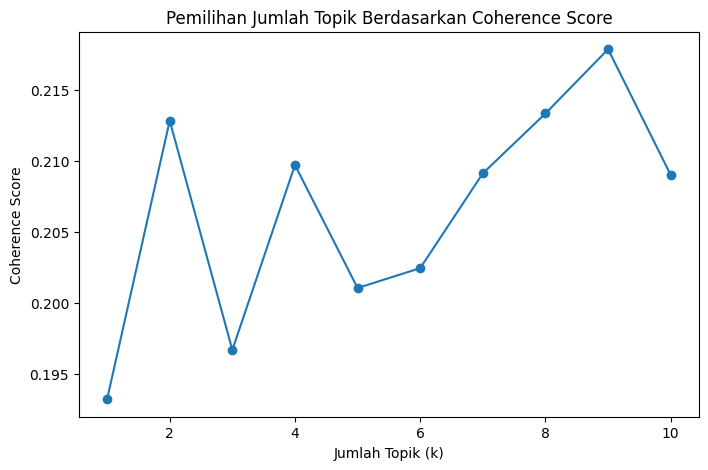

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, coherences, marker='o', linestyle='-')
plt.xlabel("Jumlah Topik (k)")
plt.ylabel("Coherence Score")
plt.title("Pemilihan Jumlah Topik Berdasarkan Coherence Score")
plt.show()

pyLDAvis

In [34]:
# Visualisasikan Topik
pyLDAvis.enable_notebook()

In [35]:
LDAvis_data_filepath = os.path.join('ldavis_prepared_'+str(k_values))       #menyimpan path file hasil visualisasi

In [36]:
# Mempersiapkan Data untuk Visualisasi
if 1 == 1:
    LDAvis_prepared = pyLDAvis.gensim.prepare(lda_model, corpus, dictionary)
    with open(LDAvis_data_filepath, 'wb') as f:
        pickle.dump(LDAvis_prepared, f)

with open(LDAvis_data_filepath, 'rb') as f:
    LDAvis_prepared = pickle.load(f)

LDAvis_prepared

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
4      0.014612 -0.002071       1        1  18.309164
5      0.000996 -0.069791       2        1  13.158307
8     -0.010797 -0.012529       3        1  11.620012
3     -0.110703 -0.029232       4        1  11.390527
7      0.110163 -0.000547       5        1  10.587576
1     -0.007845  0.001807       6        1  10.075804
2      0.068284  0.047510       7        1   9.625816
0     -0.010725 -0.067962       8        1   8.501976
6     -0.053987  0.132814       9        1   6.730819, topic_info=            Term        Freq       Total Category  logprob  loglift
42         citra  263.000000  263.000000  Default  30.0000  30.0000
1088       siswa  151.000000  151.000000  Default  29.0000  29.0000
10240     sampah   39.000000   39.000000  Default  28.0000  28.0000
574     penyakit  103.000000  103.000000  Default  27.0000  27.0000
157        model  550.000000  550.000000  Default  26.0000  26.0000
...          ...         ...         ...      ...      ...      ...
67       tingkat   17.188654  183.980878   Topic9  -6.1646   0.3279
56         nilai   21.036578  491.874892   Topic9  -5.9626  -0.4535
324      digital   15.184547  102.093784   Topic9  -6.2886   0.7929
314            3   16.765754  242.480770   Topic9  -6.1895   0.0269
1957   mahasiswa   16.109199  202.305107   Topic9  -6.2295   0.1681

[720 rows x 6 columns], token_table=      Topic      Freq            Term
term                                 
312       1  0.234412               0
312       2  0.082734               0
312       3  0.121343               0
312       4  0.137890               0
312       5  0.082734               0
...     ...       ...             ...
1617      8  0.058239         website
1617      9  0.009706         website
2463      8  0.900268  wisata_kuliner
8547      6  0.816768    yedroudj_net
1055      7  0.819406       ì£åâ_ì£åâ

[1737 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 6, 9, 4, 8, 2, 3, 1, 7])

Wordcloud

# Penyeimbangan Data dengan SMOTE

In [38]:
# baca data terlabel
df= pd.read_csv('dataTerlabel_noKey.csv')

In [39]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['Clean'])
Y = df['Topik']

0       6
1       7
2       7
3       3
4       6
       ..
1133    2
1134    4
1135    7
1136    2
1137    4
Name: Topik, Length: 1138, dtype: int64


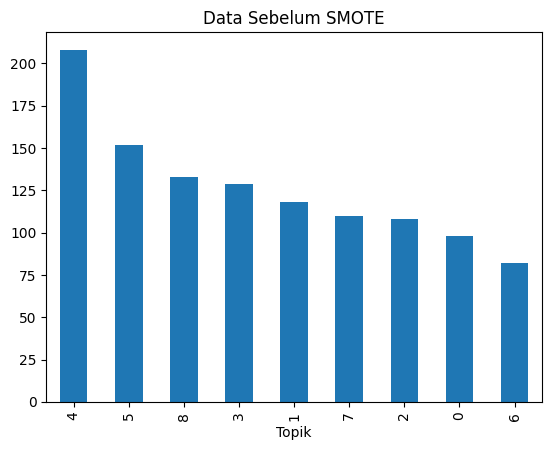

In [40]:
# menampilkan sebaran data
Y.value_counts().plot(kind='bar', title='Data Sebelum SMOTE')
print(Y)

In [41]:
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, Y_resampled = smote.fit_resample(X, Y)

# memperbarui data frame dengan fitur dan label yang sudah di oversampling
df_Smote = pd.DataFrame(X_resampled, columns=['Fitur'])
df_Smote['Label'] = Y_resampled

0       6
1       7
2       7
3       3
4       6
       ..
1867    8
1868    8
1869    8
1870    8
1871    8
Name: Topik, Length: 1872, dtype: int64


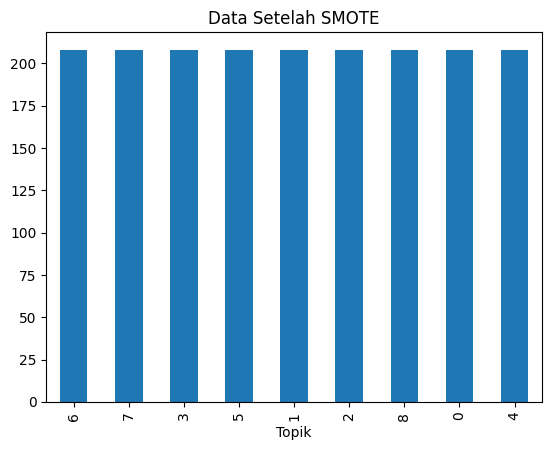

In [42]:
# menampilkan sebaran data setelah SMOTE
Y_resampled.value_counts().plot(kind='bar', title='Data Setelah SMOTE')
print(Y_resampled)

In [43]:
# simpan hasil smote
df_Smote.to_csv('dataClean_SMOTE.csv', index=False)

# Spliting Data

In [44]:
x_train, x_test, y_train, y_test = model_selection.train_test_split(X_resampled, Y_resampled, test_size=0.3)

In [45]:
x_train,y_train

(<1310x10478 sparse matrix of type '<class 'numpy.float64'>'
 	with 123095 stored elements in Compressed Sparse Row format>,
 879     3
 870     6
 745     0
 1163    0
 1550    5
        ..
 310     1
 1066    7
 1654    6
 996     6
 424     1
 Name: Topik, Length: 1310, dtype: int64)

# Pelatihan Klasifikasi

In [46]:
SVM = svm.SVC(kernel='rbf', C=100)
SVM.fit(x_train, y_train)

SVC(C=100)

In [47]:
y_pred = SVM.predict(x_test)

#### Hasil Akurasi tanpa cross validation

In [48]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[51  0  0  1  1  1  1  0  1]
 [ 0 58  0  2  6  1  0  0  3]
 [ 0  0 51  0  8  0  0  0  0]
 [ 0  0  1 42 11  1  0  0  1]
 [ 1  1  0  0 53  6  0  1  4]
 [ 1  0  0  0 19 42  1  0  3]
 [ 0  0  0  1  3  7 51  0  0]
 [ 2  0  1  1 10  0  0 51  3]
 [ 1  0  0  2  7  2  0  1 46]]
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        56
           1       0.98      0.83      0.90        70
           2       0.96      0.86      0.91        59
           3       0.86      0.75      0.80        56
           4       0.45      0.80      0.58        66
           5       0.70      0.64      0.67        66
           6       0.96      0.82      0.89        62
           7       0.96      0.75      0.84        68
           8       0.75      0.78      0.77        59

    accuracy                           0.79       562
   macro avg       0.84      0.79      0.81       562
weighted avg       0.84      0.79      0.80       562



# Simpan Model

In [49]:
joblib.dump(vectorizer, 'TFIDFvectorizer.pkl')
joblib.dump(lda_model, 'lda_model_noKey.pkl')
joblib.dump(SVM, 'svm_model.pkl')

['svm_model.pkl']

# Deployment

Load Pipeline

In [50]:
Vectorizer = joblib.load('TFIDFvectorizer.pkl')
svm_model = joblib.load('svm_model.pkl')

In [51]:
def klasifikasi(text):
  tfidf_vektor = vectorizer.transform([text])
  pred = svm_model.predict(tfidf_vektor)
  if pred == 0:
    hate = "Topik 1"
  elif pred == 1:
    hate = "Topik 2"
  elif pred == 2:
    hate = "Topik 3"
  elif pred == 3:
    hate = "Topik 4"
  elif pred == 4:
    hate = "Topik 5"
  elif pred == 5:
    hate = "Topik 6"
  elif pred == 6:
    hate = "Topik 7"
  elif pred == 7:
    hate = "Topik 8"
  elif pred == 8:
    hate = "Topik 9"
  # elif pred == 9:
  #   hate = "Topik 10"
  else:
    hate = "Error"
  return hate

In [52]:
masukkan_kalimat = str(input("Masukkan Review :"))
masukkan_kalimat = casefolding(masukkan_kalimat)
masukkan_kalimat = word_tokenize_wrapper(masukkan_kalimat)
masukkan_kalimat = stopwordText(masukkan_kalimat)
masukkan_kalimat = stemmingText(masukkan_kalimat)
masukkan_kalimat = " ".join(masukkan_kalimat)

print(masukkan_kalimat)
print("Hasil Klasifikasi :",klasifikasi(masukkan_kalimat))

kembang teknologi era bidang multimedia musik dar hibur senang tumbuh musik online tingkat musik klasifikasi dasar genre genre musik kelompok musik mirip teliti sistem bangun naive bayes classifier guna prediksi lagu dasar lirik lagu teliti dataset bagi genre blues electronic r  b christian hip hop rap rock country jazz ska dance pop soul oleh akurasi konten musik 45 konteks guna akurasi 60 kunci genre naive bayes konten musik konteks guna
Hasil Klasifikasi : Topik 5


Contoh input data baru:

1. era digital saat ini membentuk konsep baru literasi yaitu literasi digital atau literasi teknologi informasi dan komunikasi  tik   literasi tik menjadi semakin penting bagi tenaga kesehatan puskesmas di kota palembang dalam meningkatkan efisiensi dan kualitas pelayanan kesehatan  antara lain  aplikasi pelayanan kesehatan berbasis tik  penggunaan media sosial  whatsapp  facebook  instagram dan website  sebagai media informasi  promosi  komunikasi serta menyampaikan himbauan kepada masyarakat  tujuan dari penelitian ini untuk mengevaluasi tingkat kematangan literasi tik pada tenaga kesehatan terhadap aplikasi pelayanan berbasis tik dan media sosial dengan pendekatan kuantitatif yang dianalisis secara deskriptif  melalui kuesioner yang disebar ke 5  lima  puskesmas di wilayah kota palembang didapatlah 53 partisipan untuk penelitian ini  selanjutnya data dianalisa menggunakan metode people capability maturity model  p cmm   hasilnya tingkat kematangan literasi tik tenaga kesehatan puskesmas di kota palembang terhadap aplikasi pelayanan kesehatan berbasis tik berada pada level 2  repeatable  dengan rata rata indeks maturity berada diantara 0 66 Ã¢Â€Â“ 0 69  sedangkan media sosial berada pada level 2  repeatable  dengan rata rata indeks maturity berada diantara 0 65 Ã¢Â€Â“ 0 70# 

2. Dewasa ini kemajuan teknologi terasa semakin pesat, terutamapada bidang teknologi informasi. Informasi merupakan salah satu bagian untuk dapat mendukung kemajuan suatu perusahaan maupun instansi dengan tujuan memperkecil pengeluaran biaya dan mempersingkat waktu kerja. Salah satu pemanfaatan kemajuan teknologi informasi adalah pembuatan aplikasi yang berguna untuk kebutuhan sebuah perusahaan, CV. ADI SURYA MANDIRI adalah sebuah perusahaan yang bergerak dalam bidang jasa yaitu sewa alat - alat yang berkaitan dengan pesta baik itu pesta ulang tahun ataupun pernikahan. Pada penelitian ini akan menghasilkan rancangan dan implementasi dari aplikasi penyewaan alat - alat pesta untuk sebuah perusahaan.

3. Perkembangan teknologi di era saat ini di bidang multimedia, musik bukan hanya sekedar hiburan atau kesenangan. Saat ini, pertumbuhan musik online sangat meningkat, yaitu musik dapat diklasifikasikan berdasarkan genre. Genre musik adalah pengelompokan musik menurut kemiripannya satu sama lain. Pada penelitian sebelumnya, sistem tersebut dibangun dengan Naive Bayes Classifier yang berguna untuk memprediksi lagu berdasarkan lirik lagu tersebut. Dalam penelitian kami, kami menggunakan dataset yang terbagi menjadi beberapa genre yaitu Blues, Electronic, R & B, Christian, Hip Hop / Rap, Rock, Country, Jazz, Ska, Dance, Pop, dan Soul yang memperoleh akurasi Konten Musik sebesar 45 % sedangkan untuk Konteks Pengguna mendapatkan akurasi sebesar 60%. Kata kunci: Genre, Naive Bayes, Konten Musik, Konteks Pengguna.